In [1]:
"""
SSD 配對交易滾動回測系統 (多參數網格搜索版) v2
修改摘要：
  1. 形成期標準化：改為以形成期第一天為基準，norm(t) = log(P_t) - log(P_0)
  2. 對沖比率固定為 1:1，移除 OLS Beta 計算
  3. 確認價差方向：Spread = norm_A - norm_B，Z > 2 時做多 A、做空 B
"""

import sqlite3
import warnings
import itertools
import os
from datetime import datetime
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 1：Formation（形成期模組）
# ══════════════════════════════════════════════════════════════════════════════
class Formation:
    def __init__(self, price_df: pd.DataFrame, form_start: str, form_end: str, top_n: int = 20,
                 sector_mapping: dict = None, min_tickers_for_pairing: int = 2):
        self.price_df = price_df.copy()
        self.form_start = form_start
        self.form_end = form_end
        self.top_n = top_n
        self.sector_mapping = sector_mapping or {}
        self.min_tickers_for_pairing = min_tickers_for_pairing

        self.normalized_df: pd.DataFrame = pd.DataFrame()
        # ── 修改 1：改以第一天對數價格作為基準，記錄各股第一天 log price ──
        self.log_price_day0: pd.Series = pd.Series(dtype=float)
        # ── 保留 mean/std 供向後相容（已不再使用於 normalize）──
        self.mean_prices: pd.Series = pd.Series(dtype=float)
        self.std_prices: pd.Series = pd.Series(dtype=float)
        self.ssd_records: list = []
        self.selected_pairs: pd.DataFrame = pd.DataFrame()

    def normalize_prices(self) -> pd.DataFrame:
        """
        修改 1：以形成期「第一個交易日」的對數價格為基準進行標準化。
        norm(t) = log(P_t) - log(P_0)
        即每支股票的累積對數報酬（相對第一天）。
        """
        log_prices = np.log(self.price_df)

        # 取每支股票在形成期的第一個有效對數價格
        self.log_price_day0 = log_prices.iloc[0]

        # 歸一化：各日對數價格 減去 第一天對數價格
        self.normalized_df = log_prices - self.log_price_day0

        # 保留 mean/std 以備向後相容
        self.mean_prices = log_prices.mean()
        self.std_prices  = log_prices.std()

        return self.normalized_df

    def compute_ssd(self) -> pd.DataFrame:
        if self.normalized_df.empty:
            self.normalize_prices()

        tickers = self.normalized_df.columns.tolist()
        self.ssd_records = []

        sector_groups = {}
        if self.sector_mapping:
            for ticker in tickers:
                sector = self.sector_mapping.get(ticker, "Unknown")
                sector_groups.setdefault(sector, []).append(ticker)
        else:
            sector_groups["All_Market"] = tickers

        skipped_unknown_count = 0
        for sector, sector_tickers in sector_groups.items():
            if sector == "Unknown":
                skipped_unknown_count = len(sector_tickers)
                continue

            if len(sector_tickers) < self.min_tickers_for_pairing:
                continue

            for ticker_a, ticker_b in itertools.combinations(sector_tickers, 2):
                norm_a = self.normalized_df[ticker_a].values
                norm_b = self.normalized_df[ticker_b].values

                # SSD：歸一化價格序列的平方差和
                ssd_value = np.sum((norm_a - norm_b) ** 2)

                # ── 修改 2：對沖比率固定為 1:1，不再使用 OLS 計算 Beta ──
                beta = 1.0

                # Spread = norm_B - 1.0 * norm_A（對沖比率 1:1，預期收斂）
                spread = norm_b - beta * norm_a
                spread_mean = np.mean(spread)
                spread_std  = np.std(spread, ddof=1) if len(spread) > 1 else 0.0

                self.ssd_records.append({
                    "Form_Start":   self.form_start,
                    "Form_End":     self.form_end,
                    "Sector":       sector,
                    "Ticker_A":     ticker_a,
                    "Ticker_B":     ticker_b,
                    "SSD":          round(ssd_value, 6),
                    "Hedge_Ratio":  1.0,            # 固定 1:1
                    "Spread_Mean":  round(spread_mean, 6),
                    "Spread_Std":   round(spread_std, 6)
                })

        if skipped_unknown_count > 0:
            print(f"  [Formation] 跳過 {skipped_unknown_count} 支未分類 (Unknown) 股票。")

        if not self.ssd_records:
            return pd.DataFrame()
        return pd.DataFrame(self.ssd_records).sort_values("SSD").reset_index(drop=True)

    def select_pairs(self) -> pd.DataFrame:
        ssd_df = self.compute_ssd()
        if ssd_df.empty:
            self.selected_pairs = pd.DataFrame()
            return self.selected_pairs

        selected = ssd_df.head(self.top_n).copy()
        selected["Rank"] = range(1, len(selected) + 1)

        # ── 修改 1：改記錄各股「第一天對數價格」，交易期以此為基準 ──
        log_day0_a, log_day0_b = [], []
        for _, row in selected.iterrows():
            log_day0_a.append(self.log_price_day0[row["Ticker_A"]])
            log_day0_b.append(self.log_price_day0[row["Ticker_B"]])

        selected["Log_Day0_A"] = log_day0_a
        selected["Log_Day0_B"] = log_day0_b

        # 沿用舊欄位名稱供 Trading 介面使用
        # Log_Mean_A/B 現在存放 log_day0，Log_Std_A/B 固定為 1.0（不除 std）
        selected["Log_Mean_A"] = log_day0_a
        selected["Log_Std_A"]  = 1.0
        selected["Log_Mean_B"] = log_day0_b
        selected["Log_Std_B"]  = 1.0

        self.selected_pairs = selected
        return self.selected_pairs

    def run(self) -> pd.DataFrame:
        self.normalize_prices()
        self.select_pairs()
        return self.selected_pairs

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 2：Trading（交易期模組）
# ══════════════════════════════════════════════════════════════════════════════
@dataclass
class PairState:
    """單一配對在模擬過程中的內部狀態"""
    position: int = 0
    shares_a: float = 0.0
    shares_b: float = 0.0
    entry_price_a: float = 0.0
    entry_price_b: float = 0.0
    realized_pnl: float = 0.0
    trade_entry_fee: float = 0.0
    days_held: int = 0
    is_stopped: bool = False
    cooldown_dir: int = 0
    prev_total_pnl: float = 0.0


class Trading:
    def __init__(self, price_df: pd.DataFrame, trade_dates: pd.DatetimeIndex,
                 selected_pairs: pd.DataFrame, capital_per_pair: float,
                 fee_rate: float, slippage_rate: float, stop_loss_pct: float,
                 entry_z: float, exit_z: float, zscore_window: int,
                 allow_reentry: bool = False,
                 zscore_clip: float = 10.0, min_spread_std: float = 1e-6):
        self.price_df        = price_df.copy()
        self.trade_dates     = trade_dates
        self.selected_pairs  = selected_pairs
        self.capital_per_pair = capital_per_pair

        self.friction_rate   = fee_rate + slippage_rate
        self.stop_loss_pct   = stop_loss_pct
        self.entry_z         = entry_z
        self.exit_z          = exit_z
        self.zscore_window   = zscore_window
        self.allow_reentry   = allow_reentry
        self.zscore_clip     = zscore_clip
        self.min_spread_std  = min_spread_std

        self.all_trade_logs: list = []
        self.period_pnl: float = 0.0

    def _execute_entry(self, state: PairState, z: float,
                       p_a: float, p_b: float, hedge_ratio: float) -> tuple[bool, float]:
        """
        進場邏輯。
        修改 2：對沖比率固定 1:1，兩腿資金各佔 capital_per_pair 的一半。
        修改 3：Spread = norm_B - norm_A
          Z > +entry_z  → B 高 A 低 (預期收斂) → 做多 A、做空 B（position = +1）
          Z < -entry_z  → B 低 A 高 (預期收斂) → 做空 A、做多 B（position = -1）
        """
        # 對沖比率固定 1:1，兩腿各分配一半資金
        v_a = self.capital_per_pair * 0.5
        v_b = self.capital_per_pair * 0.5

        if z > self.entry_z and state.cooldown_dir != 1:
            # Spread 偏高 (B相對高、A相對低)：預期收斂，做多 A，做空 B
            state.position  = +1
            state.shares_a  =  v_a / p_a
            state.shares_b  = -v_b / p_b
        elif z < -self.entry_z and state.cooldown_dir != -1:
            # Spread 偏低 (B相對低、A相對高)：預期收斂，做空 A，做多 B
            state.position  = -1
            state.shares_a  = -v_a / p_a
            state.shares_b  =  v_b / p_b
        else:
            return False, 0.0

        state.entry_price_a   = p_a
        state.entry_price_b   = p_b
        state.trade_entry_fee = (abs(state.shares_a) * p_a +
                                  abs(state.shares_b) * p_b) * self.friction_rate
        state.days_held = 0
        return True, -state.trade_entry_fee

    def _execute_close(self, state: PairState, current_trade_pnl: float,
                       stop_loss: bool = False):
        """處理平倉與停損邏輯"""
        state.realized_pnl += current_trade_pnl

        if stop_loss and not self.allow_reentry:
            state.is_stopped = True
        else:
            if self.allow_reentry:
                state.cooldown_dir = state.position

        state.position = 0

    def _simulate_pair(self, sector: str, ticker_a: str, ticker_b: str,
                       pair_rank: int, hedge_ratio: float,
                       form_spread_mean: float, form_spread_std: float,
                       log_mean_a: float, log_std_a: float,
                       log_mean_b: float, log_std_b: float) -> list:
        """
        核心模擬函式。
        log_mean_a / log_mean_b 現在代表「形成期第一天的對數價格」(log_day0)。
        log_std_a  / log_std_b  固定為 1.0（不再做 z-score 除法）。

        修改 1：交易期標準化
          norm_p_a(t) = log(P_a(t)) - log_day0_a
          norm_p_b(t) = log(P_b(t)) - log_day0_b

        修改 2：Hedge Ratio 固定 1.0

        修改 3：Spread = norm_p_b - norm_p_a
          Z > +entry_z → 做多 A（ENTER_LONG_A）、做空 B
          Z < -entry_z → 做空 A（ENTER_SHORT_A）、做多 B
        """
        if ticker_a not in self.price_df.columns or ticker_b not in self.price_df.columns:
            return []

        price_a = self.price_df[ticker_a].dropna()
        price_b = self.price_df[ticker_b].dropna()
        common_idx = price_a.index.intersection(price_b.index)
        price_a = price_a.loc[common_idx]
        price_b = price_b.loc[common_idx]

        if len(price_a) < 5:
            return []

        # ── 修改 1：以形成期第一天對數價格為基準 ──
        # log_mean_a 此時存放的是 log_day0_a（由 Formation.select_pairs 傳入）
        log_day0_a = log_mean_a
        log_day0_b = log_mean_b

        log_p_a = np.log(price_a)
        log_p_b = np.log(price_b)

        # 歸一化：累積對數報酬相對第一天
        norm_p_a = log_p_a - log_day0_a
        norm_p_b = log_p_b - log_day0_b

        # ── 修改 3：Spread = norm_B - norm_A（hedge_ratio 固定 1.0）──
        if self.zscore_window == 0:
            # 靜態模式：使用形成期固定的 Spread Mean/Std 計算 Z-Score
            spread   = norm_p_b - norm_p_a
            safe_std = max(form_spread_std, self.min_spread_std)
            zscore   = np.clip((spread - form_spread_mean) / safe_std,
                               -self.zscore_clip, self.zscore_clip)
            beta_series = pd.Series(1.0, index=common_idx)
        else:
            # 動態模式：滾動計算 Spread 的均值與標準差來產生 Z-Score
            spread    = norm_p_b - norm_p_a
            roll_mean = spread.rolling(window=self.zscore_window).mean()
            roll_std  = spread.rolling(window=self.zscore_window).std()
            safe_std  = np.maximum(roll_std, self.min_spread_std)
            zscore    = np.clip((spread - roll_mean) / safe_std,
                                -self.zscore_clip, self.zscore_clip)
            beta_series = pd.Series(1.0, index=common_idx)

        # 截取純交易期
        valid_idx = common_idx.intersection(self.trade_dates)
        if len(valid_idx) == 0:
            return []

        price_a     = price_a.loc[valid_idx]
        price_b     = price_b.loc[valid_idx]
        zscore      = zscore.loc[valid_idx]
        beta_series = beta_series.loc[valid_idx]

        dates_arr  = valid_idx
        zscore_arr = zscore.values
        pa_arr     = price_a.values
        pb_arr     = price_b.values
        beta_arr   = beta_series.values

        base_log = {
            "Sector":    sector,
            "Pair_Rank": pair_rank,
            "Ticker_A":  ticker_a,
            "Ticker_B":  ticker_b,
            # 保留欄位供 Performance 視覺化使用
            "Log_Mean_A": log_day0_a,
            "Log_Std_A":  1.0,
            "Log_Mean_B": log_day0_b,
            "Log_Std_B":  1.0
        }

        state      = PairState()
        daily_logs = []

        for i in range(len(dates_arr)):
            date = dates_arr[i]
            z    = 0.0 if np.isnan(zscore_arr[i]) else zscore_arr[i]
            p_a, p_b = pa_arr[i], pb_arr[i]
            c_beta = 1.0   # 固定 1:1

            unrealized_pnl    = 0.0
            closed_trade_pnl  = 0.0
            daily_delta       = 0.0
            current_status    = "HOLD_CASH"

            if state.is_stopped:
                current_status = "STOPPED"
                log_record = base_log.copy()
                log_record.update({
                    "Date": date, "Price_A": round(p_a, 4), "Price_B": round(p_b, 4),
                    "Hedge_Ratio": 1.0, "ZScore": round(float(z), 4),
                    "Position": 0, "Unrealized_PnL": 0.0,
                    "Realized_PnL":  round(float(state.realized_pnl), 4),
                    "Cumulative_PnL": round(float(state.realized_pnl), 4),
                    "Status": current_status, "Trade_PnL": 0.0,
                    "Days_Held": 0, "Daily_Delta": 0.0
                })
                daily_logs.append(log_record)
                continue

            # 冷卻期解除邏輯
            # 如果先前是 Long A (Z > entry_z 進場)，出場為 Z <= exit_z，因此冷卻解除條件也是此界線
            if state.cooldown_dir == 1 and z <= self.exit_z:
                state.cooldown_dir = 0
            # 如果先前是 Short A (Z < -entry_z 進場)，出場為 Z >= -exit_z，因此冷卻解除條件也是此界線
            elif state.cooldown_dir == -1 and z >= -self.exit_z:
                state.cooldown_dir = 0

            if state.position != 0:
                state.days_held += 1
                raw_unrealized = (state.shares_a * (p_a - state.entry_price_a) +
                                  state.shares_b * (p_b - state.entry_price_b))
                exit_fee_est   = (abs(state.shares_a) * p_a +
                                  abs(state.shares_b) * p_b) * self.friction_rate

                current_trade_pnl = raw_unrealized - state.trade_entry_fee - exit_fee_est

                if (self.stop_loss_pct > 0 and
                        (-current_trade_pnl / self.capital_per_pair) >= self.stop_loss_pct):
                    self._execute_close(state, current_trade_pnl, stop_loss=True)
                    closed_trade_pnl = current_trade_pnl
                    current_status   = "STOP_LOSS_TRIGGERED"
                else:
                    # 修改 3：出場條件與 Spread 方向一致
                    # position = 1 (Long A): 進場 Z > entry_z，出場 Z <= exit_z
                    is_exit_long  = (state.position ==  1) and (z <= self.exit_z)
                    # position = -1 (Short A): 進場 Z < -entry_z，出場 Z >= -exit_z
                    is_exit_short = (state.position == -1) and (z >= -self.exit_z)

                    if is_exit_short or is_exit_long:
                        self._execute_close(state, current_trade_pnl, stop_loss=False)
                        closed_trade_pnl = current_trade_pnl
                        current_status   = "EXIT"
                    else:
                        unrealized_pnl = raw_unrealized - state.trade_entry_fee
                        current_status = "HOLDING"
            else:
                if abs(z) > self.entry_z:
                    entered, unrealized_pnl = self._execute_entry(state, z, p_a, p_b, c_beta)
                    if entered:
                        current_status = ("ENTER_LONG_A" if state.position == 1
                                          else "ENTER_SHORT_A")
                    else:
                        current_status = "HOLD_CASH (COOLDOWN)"
                else:
                    current_status = "HOLD_CASH"

            cumulative_pnl = state.realized_pnl + unrealized_pnl
            daily_delta    = cumulative_pnl - state.prev_total_pnl
            state.prev_total_pnl = cumulative_pnl

            log_record = base_log.copy()
            log_record.update({
                "Date": date, "Price_A": round(p_a, 4), "Price_B": round(p_b, 4),
                "Hedge_Ratio": 1.0, "ZScore": round(float(z), 4),
                "Position": state.position,
                "Unrealized_PnL": round(float(unrealized_pnl), 4),
                "Realized_PnL":   round(float(state.realized_pnl), 4),
                "Cumulative_PnL": round(float(cumulative_pnl), 4),
                "Status": current_status,
                "Trade_PnL": round(float(closed_trade_pnl), 4),
                "Days_Held": state.days_held,
                "Daily_Delta": round(float(daily_delta), 4)
            })
            daily_logs.append(log_record)

            if current_status in ["STOP_LOSS_TRIGGERED", "EXIT"]:
                state.days_held = 0

            if state.is_stopped and i < len(dates_arr) - 1:
                for j in range(i + 1, len(dates_arr)):
                    rd   = dates_arr[j]
                    r_z  = 0.0 if np.isnan(zscore_arr[j]) else zscore_arr[j]
                    r_pa = pa_arr[j]
                    r_pb = pb_arr[j]

                    stop_log = base_log.copy()
                    stop_log.update({
                        "Date": rd, "Price_A": round(r_pa, 4), "Price_B": round(r_pb, 4),
                        "Hedge_Ratio": 1.0, "ZScore": round(float(r_z), 4),
                        "Position": 0, "Unrealized_PnL": 0.0,
                        "Realized_PnL":  round(float(state.realized_pnl), 4),
                        "Cumulative_PnL": round(float(state.realized_pnl), 4),
                        "Status": "STOPPED", "Trade_PnL": 0.0,
                        "Days_Held": 0, "Daily_Delta": 0.0
                    })
                    daily_logs.append(stop_log)
                break

        # 期末強制平倉
        if state.position != 0 and daily_logs:
            last_status = daily_logs[-1]["Status"]
            if last_status not in ("EXIT", "STOP_LOSS_TRIGGERED",
                                   "PERIOD_END_EXIT", "STOPPED"):
                pnl_before_last_day = (daily_logs[-2]["Cumulative_PnL"]
                                       if len(daily_logs) > 1 else 0.0)

                p_a_last, p_b_last = pa_arr[-1], pb_arr[-1]
                raw_unrealized_final = (state.shares_a * (p_a_last - state.entry_price_a) +
                                        state.shares_b * (p_b_last - state.entry_price_b))
                exit_fee = (abs(state.shares_a) * p_a_last +
                            abs(state.shares_b) * p_b_last) * self.friction_rate

                closed_trade_pnl   = raw_unrealized_final - state.trade_entry_fee - exit_fee
                state.realized_pnl += closed_trade_pnl
                daily_delta        = state.realized_pnl - pnl_before_last_day

                daily_logs[-1].update({
                    "Status":         "PERIOD_END_EXIT",
                    "Realized_PnL":   round(state.realized_pnl, 4),
                    "Cumulative_PnL": round(state.realized_pnl, 4),
                    "Unrealized_PnL": 0.0,
                    "Trade_PnL":      round(closed_trade_pnl, 4),
                    "Daily_Delta":    round(daily_delta, 4),
                    "Days_Held":      state.days_held
                })

        return daily_logs

    def run(self) -> tuple:
        self.all_trade_logs = []
        for _, row in self.selected_pairs.iterrows():
            logs = self._simulate_pair(
                sector           = row.get("Sector", "Unknown"),
                ticker_a         = row["Ticker_A"],
                ticker_b         = row["Ticker_B"],
                pair_rank        = row["Rank"],
                hedge_ratio      = 1.0,                                  # 修改 2
                form_spread_mean = float(row.get("Spread_Mean", 0.0)),
                form_spread_std  = float(row.get("Spread_Std",  1.0)),
                log_mean_a       = float(row.get("Log_Mean_A", 0.0)),    # = log_day0_a
                log_std_a        = 1.0,                                  # 修改 1
                log_mean_b       = float(row.get("Log_Mean_B", 0.0)),    # = log_day0_b
                log_std_b        = 1.0                                   # 修改 1
            )
            self.all_trade_logs.extend(logs)

        if not self.all_trade_logs:
            return pd.DataFrame(), pd.Series(dtype=float)

        log_df = pd.DataFrame(self.all_trade_logs)
        period_daily_delta = log_df.groupby("Date")["Daily_Delta"].sum()

        self.period_pnl = (float(period_daily_delta.sum())
                           if not period_daily_delta.empty else 0.0)

        return log_df, period_daily_delta

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 3：Performance（績效評估模組）
# ══════════════════════════════════════════════════════════════════════════════
class Performance:
    TRADING_DAYS_PER_YEAR = 252

    def __init__(self, initial_capital: float, output_dir: Path):
        self.initial_capital = initial_capital
        self.output_dir      = output_dir
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.period_summaries, self.all_period_logs = [], []

        self._global_daily_delta = pd.Series(dtype=float)
        self.equity_series       = pd.Series(dtype=float)

        plt.rcParams.update({
            "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
            "axes.edgecolor": "#30363d",   "axes.labelcolor": "#c9d1d9",
            "axes.titlecolor": "#f0f6fc",  "xtick.color": "#8b949e",
            "ytick.color": "#8b949e",      "text.color": "#c9d1d9"
        })

    def set_zscore_params(self, entry_z: float, exit_z: float):
        self._entry_z, self._exit_z = entry_z, exit_z

    def add_period(self, period_start: str, period_end: str,
                   trade_log_df: pd.DataFrame, period_daily_delta: pd.Series,
                   capital_deployed: float, capital_per_pair: float):
        if trade_log_df.empty or period_daily_delta.empty:
            return

        if self._global_daily_delta.empty:
            self._global_daily_delta = period_daily_delta
        else:
            self._global_daily_delta = self._global_daily_delta.add(
                period_daily_delta, fill_value=0.0)

        period_pnl_abs = float(period_daily_delta.sum())

        pair_traded = trade_log_df.groupby(["Ticker_A", "Ticker_B"])["Position"].apply(
            lambda x: (x != 0).any())
        n_traded    = int(pair_traded.sum())
        n_nominated = len(pair_traded)
        r_cc = (period_pnl_abs / capital_deployed * 100) if capital_deployed > 0 else 0.0
        r_ec = ((period_pnl_abs / (n_traded * capital_per_pair) * 100)
                if n_traded > 0 else 0.0)

        exits = trade_log_df[trade_log_df["Status"].isin(
            ["EXIT", "STOP_LOSS_TRIGGERED", "PERIOD_END_EXIT"])]
        exits        = exits[exits["Trade_PnL"] != 0]
        trade_count  = len(exits)
        win_trades   = len(exits[exits["Trade_PnL"] > 0])
        gross_profit = exits[exits["Trade_PnL"] > 0]["Trade_PnL"].sum()
        gross_loss   = abs(exits[exits["Trade_PnL"] < 0]["Trade_PnL"].sum())

        stop_losses      = len(trade_log_df[trade_log_df["Status"] == "STOP_LOSS_TRIGGERED"])
        forced_exits     = len(trade_log_df[trade_log_df["Status"] == "PERIOD_END_EXIT"])
        payoff_ratio     = (gross_profit / gross_loss) if gross_loss > 0 else np.nan
        avg_holding_days = exits["Days_Held"].mean() if trade_count > 0 else 0.0

        log_copy = trade_log_df.copy()
        log_copy["Period_Start"] = period_start
        log_copy["Period_End"]   = period_end
        self.all_period_logs.append(log_copy)

        self.period_summaries.append({
            "Period_Start": period_start, "Period_End": period_end,
            "Capital_Deployed": round(capital_deployed, 2),
            "Period_PnL_USD": round(period_pnl_abs, 2),
            "R_CC_Pct": round(r_cc, 4), "R_EC_Pct": round(r_ec, 4),
            "Nominated_Pairs": n_nominated, "Traded_Pairs": n_traded,
            "Trade_Count": trade_count, "Win_Trades": win_trades,
            "Stop_Loss_Count": stop_losses, "Forced_Exit_Count": forced_exits,
            "Avg_Hold_Days": round(avg_holding_days, 1),
            "Payoff_Ratio": payoff_ratio
        })

    def _plot_summary(self, report: dict):
        fig, ax = plt.subplots(figsize=(8, 6))
        fig.patch.set_facecolor("#0d1117")
        ax.axis("off")

        cell_text = [[k, v] for k, v in report.items()]
        table = ax.table(cellText=cell_text, colLabels=["Metric", "Value"],
                         loc="center", cellLoc="left")
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2)

        for (row, col), cell in table.get_celld().items():
            cell.set_edgecolor("#30363d")
            if row == 0:
                cell.set_facecolor("#21262d")
                cell.set_text_props(color="#f0f6fc", weight="bold")
            else:
                cell.set_facecolor("#161b22")
                cell.set_text_props(color="#c9d1d9")
            if col == 0: cell.set_width(0.6)
            else:        cell.set_width(0.4)

        ax.set_title("📊 Performance Summary", color="#f0f6fc",
                     fontsize=14, fontweight="bold", pad=15)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(self.output_dir / "summary_report.png", dpi=150,
                    bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)

    def generate_report(self, quiet=True) -> dict:
        if not self.period_summaries or self._global_daily_delta.empty:
            return {}

        self._global_daily_delta.sort_index(inplace=True)
        self.equity_series = self.initial_capital + self._global_daily_delta.cumsum()

        final_eq  = self.equity_series.iloc[-1]
        pnl_abs   = final_eq - self.initial_capital
        ratio     = final_eq / self.initial_capital
        ann_ret   = ((ratio ** (self.TRADING_DAYS_PER_YEAR / len(self.equity_series)) - 1)
                     if ratio > 0 else -1.0)

        daily_ret = self.equity_series.pct_change().dropna()
        sharpe    = (ann_ret / (daily_ret.std() * np.sqrt(self.TRADING_DAYS_PER_YEAR))
                     if daily_ret.std() > 0 else 0.0)

        cummax = self.equity_series.cummax()
        mdd    = ((self.equity_series - cummax) / cummax).min()

        df_summ = pd.DataFrame(self.period_summaries)

        period_win_rate = (sum(1 for p in self.period_summaries if p["Period_PnL_USD"] > 0)
                           / len(self.period_summaries))

        total_trades     = df_summ["Trade_Count"].sum()
        total_win_trades = df_summ["Win_Trades"].sum()
        trade_win_rate   = (total_win_trades / total_trades) if total_trades > 0 else 0.0

        total_stop_losses  = df_summ["Stop_Loss_Count"].sum()
        total_forced_exits = df_summ["Forced_Exit_Count"].sum()

        valid_payoffs = df_summ["Payoff_Ratio"].dropna()
        avg_payoff    = valid_payoffs.mean() if not valid_payoffs.empty else 0.0

        report = {
            "Final Equity":          round(final_eq, 2),
            "Total PnL (%)":         round(pnl_abs / self.initial_capital * 100, 2),
            "Annualized Return (%)": round(ann_ret * 100, 2),
            "Sharpe Ratio":          round(sharpe, 2),
            "Max Drawdown (%)":      round(mdd * 100, 2),
            "Period Win Rate (%)":   round(period_win_rate * 100, 1),
            "Trade Win Rate (%)":    round(trade_win_rate * 100, 1),
            "Total Trades":          int(total_trades),
            "Stop Losses":           int(total_stop_losses),
            "Forced Exits":          int(total_forced_exits),
            "Avg Payoff Ratio":      round(avg_payoff, 2),
            "Avg R_CC (%)":          round(df_summ["R_CC_Pct"].mean(), 2),
            "Avg R_EC (%)":          round(df_summ["R_EC_Pct"].mean(), 2)
        }

        self._plot_summary(report)

        equity_df = self.equity_series.reset_index()
        equity_df.columns = ["Date", "Equity"]
        equity_df["Daily_Return"] = (self._global_daily_delta.values /
                                     (equity_df["Equity"].values -
                                      self._global_daily_delta.values))
        equity_df["Drawdown"] = equity_df["Equity"] / equity_df["Equity"].cummax() - 1

        self._plot_performance(equity_df, df_summ)
        if self.all_period_logs:
            self._plot_best_worst_pairs()
            full_log_df = pd.concat(self.all_period_logs, ignore_index=True)
            full_log_df.to_csv(self.output_dir / "detailed_trade_logs.csv", index=False)

        return report

    def _plot_performance(self, equity_df, period_df):
        fig = plt.figure(figsize=(16, 12))
        gs  = GridSpec(3, 2, figure=fig,
                       height_ratios=[2.5, 1.0, 1.5], hspace=0.25, wspace=0.25)
        ax1 = fig.add_subplot(gs[0, :])
        ax2 = fig.add_subplot(gs[1, :], sharex=ax1)
        ax3 = fig.add_subplot(gs[2, 0])
        ax4 = fig.add_subplot(gs[2, 1])

        dates, equity_val = pd.to_datetime(equity_df["Date"]), equity_df["Equity"].values

        ax1.plot(dates, equity_val, color="#58a6ff", linewidth=1.5, label="Equity")
        ax1.set_title("Equity Curve", color="#f0f6fc")
        ax1.set_ylabel("Equity (USD)", color="#58a6ff")
        ax1.tick_params(axis='y', labelcolor="#58a6ff")
        ax1.tick_params(axis='x', labelbottom=False)
        ax1.legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d")
        ax1.xaxis.set_major_locator(mdates.YearLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax1.grid(axis='x', linestyle='--', alpha=0.3, color='#8b949e')

        drawdown = equity_df["Drawdown"].values * 100
        ax2.fill_between(dates, drawdown, 0, color="#da3633", alpha=0.6, label="Drawdown (%)")
        ax2.plot(dates, drawdown, color="#da3633", linewidth=0.8)
        ax2.set_ylabel("MDD (%)", color="#da3633")
        ax2.tick_params(axis='y', labelcolor="#da3633")
        ax2.legend(loc="lower left", facecolor="#161b22", edgecolor="#30363d")
        ax2.tick_params(axis='x', labelcolor="#8b949e", rotation=0)
        ax2.grid(axis='x', linestyle='--', alpha=0.3, color='#8b949e')

        if not period_df.empty:
            x, w = np.arange(len(period_df)), 0.35
            ax3.bar(x - w/2, period_df["R_CC_Pct"].values, w,
                    label="R_CC (Committed)", color="#58a6ff", alpha=0.85)
            ax3.bar(x + w/2, period_df["R_EC_Pct"].values, w,
                    label="R_EC (Employed)", color="#ffa657", alpha=0.85)
            ax3.set_xticks(x)
            ax3.set_xticklabels([f"P{i+1}" for i in range(len(period_df))], fontsize=7)
            ax3.axhline(0, color="#8b949e", linewidth=0.7)
            ax3.set_title("Return per Rolling Period (%)", color="#f0f6fc")
            ax3.legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=9)

        daily_ret = equity_df["Daily_Return"].dropna().values * 100
        ax4.hist(daily_ret, bins=50, color="#58a6ff", alpha=0.85)
        ax4.set_title("Daily Return Distribution (%)", color="#f0f6fc")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(self.output_dir / "performance_chart.png", dpi=150,
                    bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)

    def _plot_best_worst_pairs(self):
        full_log  = pd.concat(self.all_period_logs, ignore_index=True)
        pair_perf = full_log.sort_values("Date").groupby(
            ["Ticker_A", "Ticker_B", "Period_Start"]
        )["Realized_PnL"].last().reset_index(name="Final_PnL")

        pair_perf = pair_perf.sort_values("Final_PnL")
        if len(pair_perf) < 3:
            return

        targets = [
            ("Best",   pair_perf.iloc[-1]),
            ("Median", pair_perf.iloc[len(pair_perf) // 2]),
            ("Worst",  pair_perf.iloc[0])
        ]
        fig, axes = plt.subplots(3, 3, figsize=(18, 12),
                                 gridspec_kw={"height_ratios": [2.2, 1.4, 1.4],
                                              "hspace": 0.35})
        fig.patch.set_facecolor("#0d1117")

        for col_idx, (label, row) in enumerate(targets):
            mask = ((full_log["Ticker_A"]     == row["Ticker_A"]) &
                    (full_log["Ticker_B"]     == row["Ticker_B"]) &
                    (full_log["Period_Start"] == row["Period_Start"]))
            seg = full_log[mask].sort_values("Date")
            if seg.empty:
                continue

            dates, zscore, cum_pnl = (seg["Date"].values,
                                      seg["ZScore"].values,
                                      seg["Cumulative_PnL"].values)
            status = seg["Status"].values

            # ── 修改 1：視覺化改用 day0 基準的累積對數報酬 ──
            log_a = np.log(seg["Price_A"].values)
            log_b = np.log(seg["Price_B"].values)

            log_day0_a_plot = seg["Log_Mean_A"].iloc[0]   # 已存放 log_day0
            log_day0_b_plot = seg["Log_Mean_B"].iloc[0]

            norm_a = log_a - log_day0_a_plot
            norm_b = log_b - log_day0_b_plot

            # 相對第一個交易日起始做平移（從 0 出發方便比較）
            plot_a = norm_a - norm_a[0]
            plot_b = norm_b - norm_b[0]

            axes[0, col_idx].plot(dates, plot_a, label=row["Ticker_A"], color="#58a6ff")
            axes[0, col_idx].plot(dates, plot_b, label=row["Ticker_B"], color="#ffa657")

            sector = seg["Sector"].iloc[0] if "Sector" in seg.columns else "Unknown"

            for i, s in enumerate(status):
                y_mid = (plot_a[i] + plot_b[i]) / 2
                if s == "ENTER_LONG_A":
                    axes[0, col_idx].scatter(dates[i], plot_a[i],
                                             marker="^", s=80, color="#3fb950", zorder=5)
                    axes[0, col_idx].scatter(dates[i], plot_b[i],
                                             marker="v", s=80, color="#f85149", zorder=5)
                elif s == "ENTER_SHORT_A":
                    axes[0, col_idx].scatter(dates[i], plot_a[i],
                                             marker="v", s=80, color="#f85149", zorder=5)
                    axes[0, col_idx].scatter(dates[i], plot_b[i],
                                             marker="^", s=80, color="#3fb950", zorder=5)
                elif s in ("EXIT", "PERIOD_END_EXIT"):
                    axes[0, col_idx].scatter(dates[i], y_mid,
                                             marker="o", s=50, color="#ffa657", zorder=5)
                elif s == "STOP_LOSS_TRIGGERED":
                    axes[0, col_idx].scatter(dates[i], y_mid,
                                             marker="X", s=90, color="#ff7b72", zorder=5)

            axes[0, col_idx].set_title(
                f"{label}: [{sector[:10]}] {row['Ticker_A']}/{row['Ticker_B']}",
                color="#f0f6fc", fontsize=10)
            axes[0, col_idx].legend(loc="upper left", facecolor="#161b22",
                                    edgecolor="#30363d", fontsize=8)

            axes[1, col_idx].plot(dates, zscore, color="#d2a8ff", label="Z-Score")
            axes[1, col_idx].axhline(self._entry_z,  color="#3fb950", linestyle="--",
                                     label="Long A Entry")
            axes[1, col_idx].axhline(-self._entry_z, color="#f85149", linestyle="--",
                                     label="Short A Entry")
            axes[1, col_idx].axhline(self._exit_z,   color="#8b949e", linestyle=":",
                                     label="Exit Target")
            axes[1, col_idx].legend(loc="upper left", facecolor="#161b22",
                                    edgecolor="#30363d", fontsize=8)

            axes[2, col_idx].plot(dates, cum_pnl,
                                  color="#3fb950" if cum_pnl[-1] >= 0 else "#f85149",
                                  label="Cum PnL")
            axes[2, col_idx].axhline(0, color="#8b949e", linestyle=":", linewidth=1)
            axes[2, col_idx].legend(loc="upper left", facecolor="#161b22",
                                    edgecolor="#30363d", fontsize=8)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(self.output_dir / "pair_trades_chart.png", dpi=150,
                    bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 4：DataProcessor（數據清理與前置處理模組）
# ══════════════════════════════════════════════════════════════════════════════
class DataProcessor:
    def __init__(self, db_path: str, table_name: str = "daily_prices"):
        self.db_path, self.table_name = db_path, table_name
    
    def load_sector_mapping(self, info_table: str, ticker_col: str = "ticker",
                            sector_col: str = "sector") -> dict:
        try:
            conn = sqlite3.connect(self.db_path)
            df   = pd.read_sql_query(
                f"SELECT {ticker_col}, {sector_col} FROM {info_table}", conn)
            conn.close()
            mapping = {}
            for k, v in zip(df[ticker_col], df[sector_col]):
                if pd.notna(k) and pd.notna(v):
                    mapping[str(k).strip().upper()] = str(v).strip()
            print(f"✅ 成功載入產業分類表 '{info_table}'，共取得 {len(mapping)} 檔標的分類。")
            return mapping
        except Exception as e:
            print(f"⚠️ [警告] 無法載入產業分類表 '{info_table}'！錯誤原因：{e}")
            print(f"⚠️ 系統將退回「全市場(All_Market)」跨產業配對模式。")
            return {}

    def prepare_backtest_data(self, backtest_start: str, backtest_end: str,
                              formation_window: int):
        conn   = sqlite3.connect(self.db_path)
        raw_df = pd.read_sql_query(
            f"SELECT date, ticker, COALESCE(adj_close, close) AS price "
            f"FROM {self.table_name} "
            f"WHERE COALESCE(adj_close, close) IS NOT NULL ORDER BY date ASC", conn)
        conn.close()

        raw_df["date"]  = pd.to_datetime(raw_df["date"])
        raw_df["price"] = pd.to_numeric(raw_df["price"], errors="coerce")
        raw_df.dropna(subset=["price"], inplace=True)
        raw_df = raw_df[raw_df["price"] > 0]

        price_pivot = raw_df.pivot_table(
            index="date", columns="ticker", values="price",
            aggfunc="last").sort_index()
        price_pivot = price_pivot.loc[:, price_pivot.isnull().mean() < 0.20].ffill(limit=5)
        price_pivot.dropna(axis=1, thresh=int(len(price_pivot) * 0.9), inplace=True)

        def _safe_parse(d_str, is_end=False):
            if not d_str: return None
            try:
                dt = pd.to_datetime(str(d_str).strip())
                if is_end and len(str(d_str).strip()) == 7:
                    return dt + pd.offsets.MonthEnd(0)
                return dt
            except Exception:
                return None

        bt_start_ts = _safe_parse(backtest_start)
        bt_end_ts   = _safe_parse(backtest_end, is_end=True)
        all_dates   = price_pivot.index.tolist()

        start_indices = ([i for i, d in enumerate(all_dates) if d >= bt_start_ts]
                         if bt_start_ts else [])
        first_idx     = start_indices[0] if start_indices else 0

        data_slice_start = (all_dates[max(0, first_idx - formation_window)]
                            if bt_start_ts else price_pivot.index[0])
        data_slice_end   = bt_end_ts if bt_end_ts else price_pivot.index[-1]
        price_pivot      = price_pivot.loc[data_slice_start:data_slice_end]

        sliced_dates      = price_pivot.index.tolist()
        new_start_indices = ([i for i, d in enumerate(sliced_dates) if d >= bt_start_ts]
                             if bt_start_ts else [])
        local_first_trade_idx = (new_start_indices[0] if new_start_indices
                                 else formation_window)

        return price_pivot, sliced_dates, len(price_pivot), max(local_first_trade_idx,
                                                                 formation_window)

ℹ️ 產業分類配驚已關閉，系統將進行全市場全標的配對。

🚀 開始進行 Grid Search，共 294 期，每期處理 27 種參數組合...
  ▶ 處理中：第 01 期 (交易: 2001-01-02 ~ 2001-07-02)
  ▶ 處理中：第 02 期 (交易: 2001-02-01 ~ 2001-08-01)
  ▶ 處理中：第 03 期 (交易: 2001-03-05 ~ 2001-08-30)
  ▶ 處理中：第 04 期 (交易: 2001-04-03 ~ 2001-10-05)
  ▶ 處理中：第 05 期 (交易: 2001-05-03 ~ 2001-11-05)
  ▶ 處理中：第 06 期 (交易: 2001-06-04 ~ 2001-12-05)
  ▶ 處理中：第 07 期 (交易: 2001-07-03 ~ 2002-01-07)
  ▶ 處理中：第 08 期 (交易: 2001-08-02 ~ 2002-02-06)
  ▶ 處理中：第 09 期 (交易: 2001-08-31 ~ 2002-03-08)
  ▶ 處理中：第 10 期 (交易: 2001-10-08 ~ 2002-04-09)
  ▶ 處理中：第 11 期 (交易: 2001-11-06 ~ 2002-05-08)
  ▶ 處理中：第 12 期 (交易: 2001-12-06 ~ 2002-06-07)
  ▶ 處理中：第 13 期 (交易: 2002-01-08 ~ 2002-07-09)
  ▶ 處理中：第 14 期 (交易: 2002-02-07 ~ 2002-08-07)
  ▶ 處理中：第 15 期 (交易: 2002-03-11 ~ 2002-09-06)
  ▶ 處理中：第 16 期 (交易: 2002-04-10 ~ 2002-10-07)
  ▶ 處理中：第 17 期 (交易: 2002-05-09 ~ 2002-11-05)
  ▶ 處理中：第 18 期 (交易: 2002-06-10 ~ 2002-12-05)
  ▶ 處理中：第 19 期 (交易: 2002-07-10 ~ 2003-01-07)
  ▶ 處理中：第 20 期 (交易: 2002-08-08 ~ 2003-02-06)
  ▶ 處理中：第 21 期 (交易: 2002-09

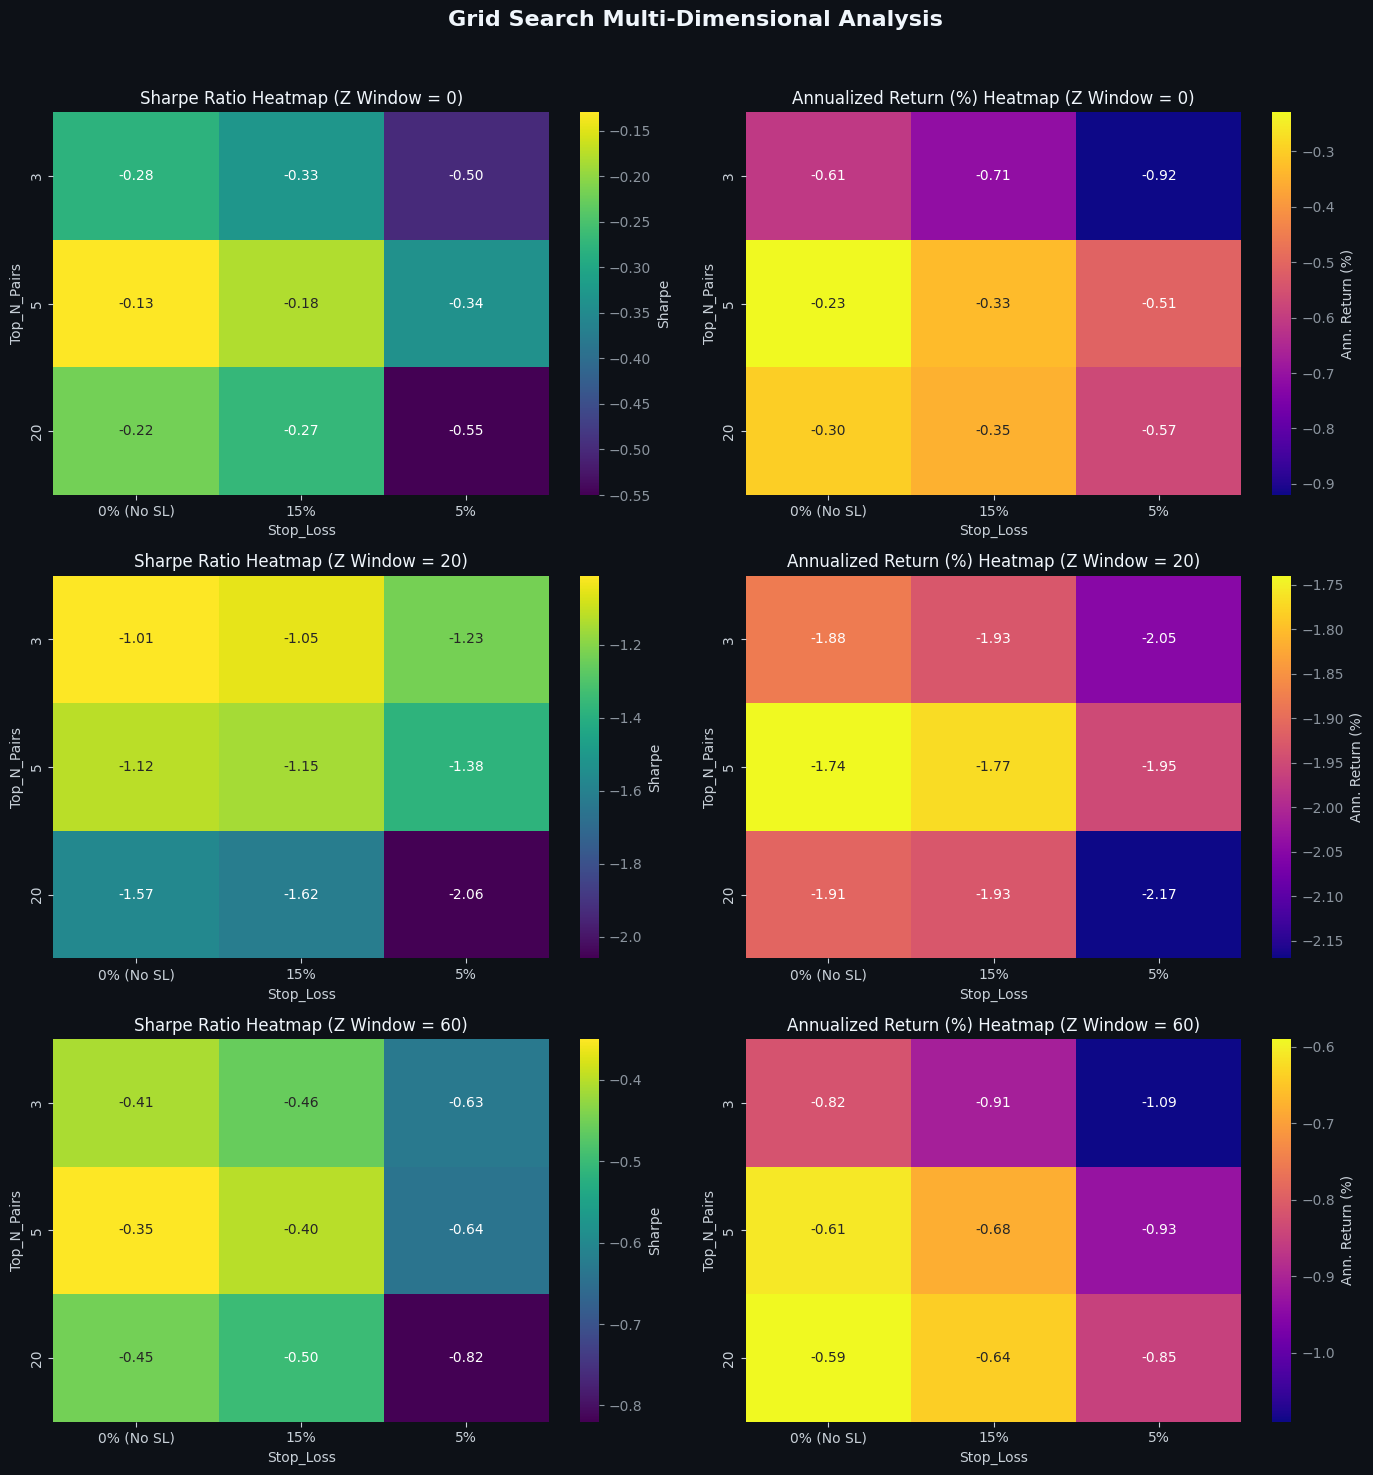

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 主程式：自動參數網格搜尋 (Grid Search)
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    MIN_TICKERS_FOR_PAIRING = 2
    ZSCORE_CLIP             = 10.0
    MIN_SPREAD_STD          = 1e-6

    DB_PATH, TABLE_NAME          = r"../data/sp500.db", "daily_prices"
    BACKTEST_START, BACKTEST_END = "2000-01", "2025-12"
    INFO_TABLE_NAME, TICKER_COL_NAME, SECTOR_COL_NAME = "company_info", "ticker", "sector"

    TOP_N_LIST         = [3, 5, 20]
    STOP_LOSS_LIST     = [0, 0.05, 0.15]
    ZSCORE_WINDOW_LIST = [0, 20, 60]

    ENTRY_Z = 2.0
    EXIT_Z  = 0.0

    FORMATION_WINDOW, TRADING_WINDOW, ROLLING_STEP = 252, 126, 21

    FEE_RATE        = 0.001
    SLIPPAGE_RATE   = 0.001
    INITIAL_CAPITAL = 10000

    ALLOW_REENTRY      = True
    USE_SECTOR_PAIRING = False

    OUTPUT_DIR = Path(r"../results/bSSD_ReEntry_NoSector")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    processor = DataProcessor(db_path=DB_PATH, table_name=TABLE_NAME)

    if USE_SECTOR_PAIRING:
        sector_mapping = processor.load_sector_mapping(
            INFO_TABLE_NAME, TICKER_COL_NAME, SECTOR_COL_NAME)
    else:
        sector_mapping = {}
        print("ℹ️ 產業分類配驚已關閉，系統將進行全市場全標的配對。")

    price_pivot, all_dates, total_days, local_first_trade_idx = \
        processor.prepare_backtest_data(BACKTEST_START, BACKTEST_END, FORMATION_WINDOW)

    max_concurrent = TRADING_WINDOW // ROLLING_STEP
    states = {}

    for n, sl, z_win in itertools.product(TOP_N_LIST, STOP_LOSS_LIST, ZSCORE_WINDOW_LIST):
        sub_dir = OUTPUT_DIR / f"Top{n}_SL{int(sl*100)}_ZWin{z_win}"
        perf    = Performance(initial_capital=INITIAL_CAPITAL, output_dir=sub_dir)
        perf.set_zscore_params(entry_z=ENTRY_Z, exit_z=EXIT_Z)
        states[(n, sl, z_win)] = {
            "perf":  perf,
            "slots": [{"avail_idx": 0, "capital": INITIAL_CAPITAL / max_concurrent}
                      for _ in range(max_concurrent)]
        }

    roll_start_indices = list(range(local_first_trade_idx,
                                   total_days - TRADING_WINDOW + 1,
                                   ROLLING_STEP))
    print(f"\n🚀 開始進行 Grid Search，共 {len(roll_start_indices)} 期，"
          f"每期處理 {len(states)} 種參數組合...")

    for roll_idx, trade_start_idx in enumerate(roll_start_indices):
        form_start_idx = trade_start_idx - FORMATION_WINDOW
        form_end_idx   = trade_start_idx
        trade_end_idx  = min(trade_start_idx + TRADING_WINDOW, total_days)

        form_data  = price_pivot.iloc[form_start_idx:form_end_idx]
        trade_data = price_pivot.iloc[trade_start_idx:trade_end_idx]
        valid_cols = (form_data.isnull().sum() + trade_data.isnull().sum()) == 0

        form_data   = form_data.loc[:, valid_cols]
        trade_dates = trade_data.index

        extended_trade_start_idx = max(0, trade_start_idx - max(ZSCORE_WINDOW_LIST))
        extended_trade_data = price_pivot.iloc[
            extended_trade_start_idx:trade_end_idx].loc[:, valid_cols]

        if form_data.shape[1] < 2 or trade_data.empty:
            continue

        trade_start_str = str(all_dates[trade_start_idx])[:10]
        trade_end_str   = str(all_dates[trade_end_idx - 1])[:10]
        form_start_str  = str(all_dates[form_start_idx])[:10]
        form_end_str    = str(all_dates[form_end_idx - 1])[:10]
        print(f"  ▶ 處理中：第 {roll_idx+1:02d} 期 "
              f"(交易: {trade_start_str} ~ {trade_end_str})")

        formation = Formation(
            price_df=form_data,
            form_start=form_start_str,
            form_end=form_end_str,
            top_n=max(TOP_N_LIST),
            sector_mapping=sector_mapping,
            min_tickers_for_pairing=MIN_TICKERS_FOR_PAIRING
        )
        max_selected_pairs = formation.run()

        if max_selected_pairs.empty:
            continue

        for n, sl, z_win in itertools.product(TOP_N_LIST, STOP_LOSS_LIST, ZSCORE_WINDOW_LIST):
            selected_pairs = max_selected_pairs.head(n)
            state  = states[(n, sl, z_win)]
            slots  = state["slots"]

            free_slots = [i for i, s in enumerate(slots)
                          if s["avail_idx"] <= trade_start_idx]
            if free_slots:
                slot_idx = free_slots[0]
            else:
                slot_idx = min(range(max_concurrent),
                               key=lambda i: slots[i]["avail_idx"])

            current_period_capital   = slots[slot_idx]["capital"]
            current_capital_per_pair = current_period_capital / n

            trading = Trading(
                price_df         = extended_trade_data,
                trade_dates      = trade_dates,
                selected_pairs   = selected_pairs,
                capital_per_pair = current_capital_per_pair,
                fee_rate         = FEE_RATE,
                slippage_rate    = SLIPPAGE_RATE,
                stop_loss_pct    = sl,
                entry_z          = ENTRY_Z,
                exit_z           = EXIT_Z,
                zscore_window    = z_win,
                allow_reentry    = ALLOW_REENTRY,
                zscore_clip      = ZSCORE_CLIP,
                min_spread_std   = MIN_SPREAD_STD
            )

            trade_log_df, period_daily_delta = trading.run()
            period_pnl = trading.period_pnl if not trade_log_df.empty else 0.0

            slots[slot_idx]["capital"]   = max(0, current_period_capital + period_pnl)
            slots[slot_idx]["avail_idx"] = trade_end_idx

            state["perf"].add_period(
                trade_start_str, trade_end_str,
                trade_log_df, period_daily_delta,
                current_period_capital, current_capital_per_pair)

    summary_results = []
    print("\n✅ 回測完成！正在產生總結報表...")
    for (n, sl, z_win), state in states.items():
        report = state["perf"].generate_report(quiet=True)
        if report:
            report["Z_Window"]    = z_win
            report["Top_N_Pairs"] = n
            report["Stop_Loss"]   = f"{sl*100:.0f}%" if sl > 0 else "0% (No SL)"
            summary_results.append(report)

    if not summary_results:
        print("⚠️ 無有效交易紀錄，請檢查資料或參數設定。")
    else:
        summary_df = pd.DataFrame(summary_results)
        cols = ["Z_Window", "Top_N_Pairs", "Stop_Loss",
                "Annualized Return (%)", "Sharpe Ratio", "Max Drawdown (%)",
                "Period Win Rate (%)", "Trade Win Rate (%)", "Total Trades",
                "Stop Losses", "Forced Exits", "Avg Payoff Ratio", "Avg R_EC (%)"]
        summary_df = summary_df[cols].sort_values("Sharpe Ratio", ascending=False)
        summary_df.to_csv(OUTPUT_DIR / "grid_search_summary.csv", index=False)

        plt.rcParams.update({"figure.facecolor": "#0d1117",
                             "axes.facecolor": "#161b22",
                             "text.color": "#c9d1d9"})
        fig, axes = plt.subplots(len(ZSCORE_WINDOW_LIST), 2,
                                 figsize=(14, 5 * len(ZSCORE_WINDOW_LIST)),
                                 squeeze=False)
        fig.patch.set_facecolor("#0d1117")

        for idx, z_win in enumerate(ZSCORE_WINDOW_LIST):
            df_sub = summary_df[summary_df["Z_Window"] == z_win]
            if df_sub.empty:
                continue

            pivot_sharpe  = df_sub.pivot(index="Top_N_Pairs", columns="Stop_Loss",
                                         values="Sharpe Ratio")
            pivot_ann_ret = df_sub.pivot(index="Top_N_Pairs", columns="Stop_Loss",
                                         values="Annualized Return (%)")

            sns.heatmap(pivot_sharpe, annot=True, cmap="viridis",
                        ax=axes[idx, 0], cbar_kws={'label': 'Sharpe'}, fmt=".2f")
            axes[idx, 0].set_title(f"Sharpe Ratio Heatmap (Z Window = {z_win})",
                                   color="#f0f6fc")
            axes[idx, 0].tick_params(colors="#c9d1d9")

            sns.heatmap(pivot_ann_ret, annot=True, cmap="plasma",
                        ax=axes[idx, 1], cbar_kws={'label': 'Ann. Return (%)'}, fmt=".2f")
            axes[idx, 1].set_title(
                f"Annualized Return (%) Heatmap (Z Window = {z_win})", color="#f0f6fc")
            axes[idx, 1].tick_params(colors="#c9d1d9")

        plt.suptitle("Grid Search Multi-Dimensional Analysis",
                     color="#f0f6fc", fontsize=16, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.96])

        heatmap_file = OUTPUT_DIR / "grid_search_heatmap.png"
        fig.savefig(heatmap_file, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        plt.show()